# 20 - Perturbation integration tolerance

`tol_perturbations_integration` sets the relative error the rk evolver allows per step; the CLASS default is
1e-5. A run at 1e-4 was ~20% faster in a profile (2026-10-09). How much accuracy would looser tolerances
cost, across the masses and f̃ the emulators are trained on?

1. Error: Δχ² of 1e-5 (default), 3e-5, 1e-4 and 3e-4 against 1e-6 on a (mass, f̃) grid; f̃ = 10⁻⁶
   isolates the ΛCDM part. 1e-6 is checked against 1e-7.
2. Cost: run time per tolerance, runs one at a time.
3. Where the error sits, at the worst point.

**Result.** Keep the default 1e-5.
- Its error is negligible: Δχ² ≤ 9·10⁻⁴ against 1e-6 everywhere, largest at 10¹¹ GeV, f̃ = 0.9 (signal
  2·10⁵), at the level of the neutrino `l_max_ncdm` floor (nb19) and far below the grid error (nb17). The
  ΛCDM part is 10⁻⁸. 1e-6 agrees with 1e-7 to Δχ² ≤ 2·10⁻⁵.
- The error grows with tolerance, f̃ and warmth. At 1e-4 it reaches Δχ² 0.016 at 10¹¹ GeV, f̃ = 0.9
  (max ΔP_cb 0.3%, Δσ8_cb 2·10⁻⁴), 0.005 at f̃ = 0.5; from 10¹³ GeV up it stays ≤ 10⁻³ even at 3e-4.
  It sits on large scales, where the daughter acts late: TT at ℓ < 200 (late ISW, −0.2% at 1e-4, cosmic
  variance keeps its Δχ² small), C_ℓ^φφ at ℓ ≈ 10–300 and P_cb at k ≈ 10⁻³–0.05/Mpc, jagged in k.
- Looser tolerances save little: CPU time relative to 1e-5 is 0.89–0.98 at 1e-4 and 0.87–1.01 at 3e-4
  (no gain beyond 1e-4); 1e-6 costs +8–14%. The ~20% gain seen in the first profile was on the build
  that still integrated unborn daughter bins.

Settings of nb19 (κ = 12.1, a_t = 0.133, strategy 5, s = 0.25, DE sink on, 50 bins/decade, ΛCDM best
fit and ω_dm,tot of the 10¹⁴ GeV chain of 2026-10-07), on the build with unborn daughter bins left out
of the evolver (`6071473d`). Δχ²: `accdm_nb.compare`. Cached in `20_cache.pkl`; CPU times in `20_timing.pkl`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from accdm_nb import ELL, KK, RunCache, chi2_parts, compare, ok, show, status, plot_style

plot_style()

SETTINGS = {'N_ncdm': 2, 'N_ur': 2.0308, 'm_ncdm': '0.06, 0.1', 'deg_ncdm': '1, 1', 'T_ncdm': '0.71611, 1',
            'ncdm_quadrature_strategy': '0, 5', 'ncdm_fluid_approximation': 3, 'accdm_q_log_share': 0.25,
            'kappa_acc': 12.1, 'a_t_acc': 0.133, 'vary_Gamma_acc': 'yes', 'acc_de_sink': 'yes',
            'gauge': 'synchronous', 'reionization_z_start_max': 80, 'evolver': 0, 'k_pivot': 0.05,
            'output': 'mPk, lCl, tCl, pCl', 'P_k_max_1/Mpc': 1.0, 'lensing': 'yes', 'l_max_scalars': 2508,
            'omega_b': 0.02246728, 'omega_dm_tot': 0.1176592, 'H0': 68.34158, 'ln10^{10}A_s': 3.052865,
            'n_s': 0.9694445, 'tau_reio': 0.06127875}
MASSES = [11, 12, 13, 14, 16, 18]
F_GRID = [0.01, 0.1, 0.5, 0.9]
TOLS, REF, F_NULL = [1e-5, 3e-5, 1e-4, 3e-4], 1e-6, 1e-6


def params(log10m, f_tilde, tol):
    return {**SETTINGS, 'm_acc_in_GeV': 10.0**log10m, 'f_tilde': f_tilde, 'tol_perturbations_integration': tol}

## 1. Error against 1e-6

In [2]:
cache = RunCache('20_cache.pkl', workers=8)
POINTS = [(14, F_NULL)] + [(lm, ft) for lm in MASSES for ft in F_GRID]
jobs = {(lm, ft, tol): params(lm, ft, tol) for lm, ft in POINTS for tol in TOLS + [REF]}
CHECK = [(11, 0.5), (14, 0.1), (18, 0.9)]
jobs.update({(lm, ft, 1e-7): params(lm, ft, 1e-7) for lm, ft in CHECK})
res = dict(zip(jobs, cache.many(list(jobs.values()))))
print('failed:', [(k, status(v)) for k, v in res.items() if not ok(v)] or 'none')

null = res[(14, F_NULL, REF)]
rows = []
for lm, ft in POINTS:
    ref = res[(lm, ft, REF)]
    c4 = compare(res[(lm, ft, 1e-4)], ref)
    rows.append({'log10 m': lm, 'f̃': ft, 'signal': chi2_parts(ref, null)['total'] if ft != F_NULL else np.nan,
                 **{'Δχ² {:.0e}'.format(tol): compare(res[(lm, ft, tol)], ref)['total'] for tol in TOLS},
                 '1e-4: lens': c4['lens'], '1e-4: max ΔP_cb': c4['dpk'], '1e-4: Δσ8_cb': c4['dsigma8']})
table = pd.DataFrame(rows).set_index(['log10 m', 'f̃'])
show(table, {'1e-4: Δσ8_cb': '{:+.1e}'}, default='{:.2e}')
for lm, ft in CHECK:
    c = compare(res[(lm, ft, REF)], res[(lm, ft, 1e-7)])
    print('reference error at log10 m = {:g}, f̃ = {:g}: Δχ²(1e-6 vs 1e-7) = {:.1e}, Δσ8_cb = {:+.1e}'.format(
        lm, ft, c['total'], c['dsigma8']))

failed: none


signal Δχ² 1e-05 Δχ² 3e-05 Δχ² 1e-04 Δχ² 3e-04 1e-4: lens  \
log10 m f̃                                                                      
14      0.000001         -  1.07e-08  9.34e-08  8.52e-07  3.15e-06   1.29e-11   
11      0.010000  1.30e+01  3.50e-07  8.66e-07  2.04e-06  4.57e-06   5.68e-07   
        0.100000  1.26e+03  4.38e-05  1.21e-04  2.61e-04  4.26e-04   1.03e-05   
        0.500000  4.52e+04  3.26e-04  1.41e-03  4.95e-03  8.50e-03   1.06e-04   
        0.900000  2.12e+05  8.85e-04  4.65e-03  1.56e-02  2.06e-02   3.00e-04   
12      0.010000  8.69e-01  9.08e-08  2.45e-07  1.05e-06  3.40e-06   1.16e-07   
        0.100000  7.79e+01  6.81e-06  1.38e-05  2.63e-05  4.25e-05   7.89e-06   
        0.500000  1.80e+03  1.17e-04  5.63e-04  1.49e-03  2.28e-03   2.27e-05   
        0.900000  8.51e+03  2.33e-04  1.12e-03  3.34e-03  7.44e-03   4.42e-05   
13      0.010000  5.74e-01  6.74e-08  2.00e-07  9.91e-07  3.32e-06   8.55e-08   
        0.100000  5.02e+01  2.70e-06  6.50e-06  1.37e-05  2.21e-05   6.33e-06   
        0.500000  7.06e+02  4.46e-05  1.40e-04  3.01e-04  4.49e-04   3.55e-05   
        0.900000  1.39e+03  1.14e-04  4.44e-04  1.02e-03  1.43e-03   5.26e-05   
14      0.010000  3.19e-01  5.05e-08  1.74e-07  9.50e-07  3.28e-06   6.56e-08   
        0.100000  2.84e+01  1.67e-06  3.65e-06  8.79e-06  1.56e-05   3.88e-06   
        0.500000  4.19e+02  3.37e-05  6.83e-05  1.15e-04  2.03e-04   1.50e-05   
        0.900000  7.82e+02  7.14e-05  1.90e-04  2.90e-04  4.32e-04   1.50e-05   
16      0.010000  2.50e-03  1.64e-08  1.03e-07  8.59e-07  3.18e-06   2.05e-09   
        0.100000  2.41e-01  1.37e-06  2.02e-06  3.22e-06  5.83e-06   3.62e-08   
        0.500000  5.13e+00  3.32e-05  6.43e-05  9.10e-05  1.09e-04   7.83e-10   
        0.900000  1.37e+01  7.11e-05  1.85e-04  2.62e-04  3.19e-04   1.83e-07   
18      0.010000  1.40e-06  1.61e-08  1.02e-07  8.66e-07  3.17e-06   8.67e-10   
        0.100000  6.24e-05  1.36e-06  2.01e-06  3.18e-06  5.72e-06   1.46e-08   
        0.500000  9.56e-04  3.32e-05  6.43e-05  9.10e-05  1.09e-04   1.99e-08   
        0.900000  1.60e-02  7.10e-05  1.85e-04  2.62e-04  3.20e-04   2.91e-07   

                 1e-4: max ΔP_cb 1e-4: Δσ8_cb  
log10 m f̃                                     
14      0.000001        8.30e-07     +1.7e-07  
11      0.010000        4.87e-05     +3.9e-06  
        0.100000        5.08e-04     +1.4e-05  
        0.500000        1.94e-03     +5.1e-05  
        0.900000        3.31e-03     +1.6e-04  
12      0.010000        2.27e-05     +1.9e-06  
        0.100000        2.26e-04     +9.5e-06  
        0.500000        1.30e-03     +1.3e-05  
        0.900000        2.50e-03     +2.5e-05  
13      0.010000        1.18e-05     +1.7e-06  
        0.100000        1.89e-04     +8.4e-06  
        0.500000        1.27e-03     +1.8e-05  
        0.900000        2.20e-03     +2.9e-05  
14      0.010000        9.07e-06     +1.6e-06  
        0.100000        1.15e-04     +7.8e-06  
        0.500000        5.16e-04     +2.0e-05  
        0.900000        7.76e-04     +3.4e-05  
16      0.010000        4.86e-06     +5.9e-07  
        0.100000        4.92e-05     +2.4e-06  
        0.500000        2.89e-04     +6.6e-06  
        0.900000        4.82e-04     +1.0e-05  
18      0.010000        4.85e-06     +4.4e-07  
        0.100000        4.92e-05     +1.9e-06  
        0.500000        2.88e-04     +5.1e-06  
        0.900000        4.80e-04     +7.4e-06

reference error at log10 m = 11, f̃ = 0.5: Δχ²(1e-6 vs 1e-7) = 1.8e-05, Δσ8_cb = +5.1e-07
reference error at log10 m = 14, f̃ = 0.1: Δχ²(1e-6 vs 1e-7) = 9.1e-07, Δσ8_cb = +1.7e-07
reference error at log10 m = 18, f̃ = 0.9: Δχ²(1e-6 vs 1e-7) = 1.2e-05, Δσ8_cb = +8.9e-08


Δχ² against f̃ for each tolerance; the dashed lines mark the ΛCDM part (f̃ = 10⁻⁶) of each.

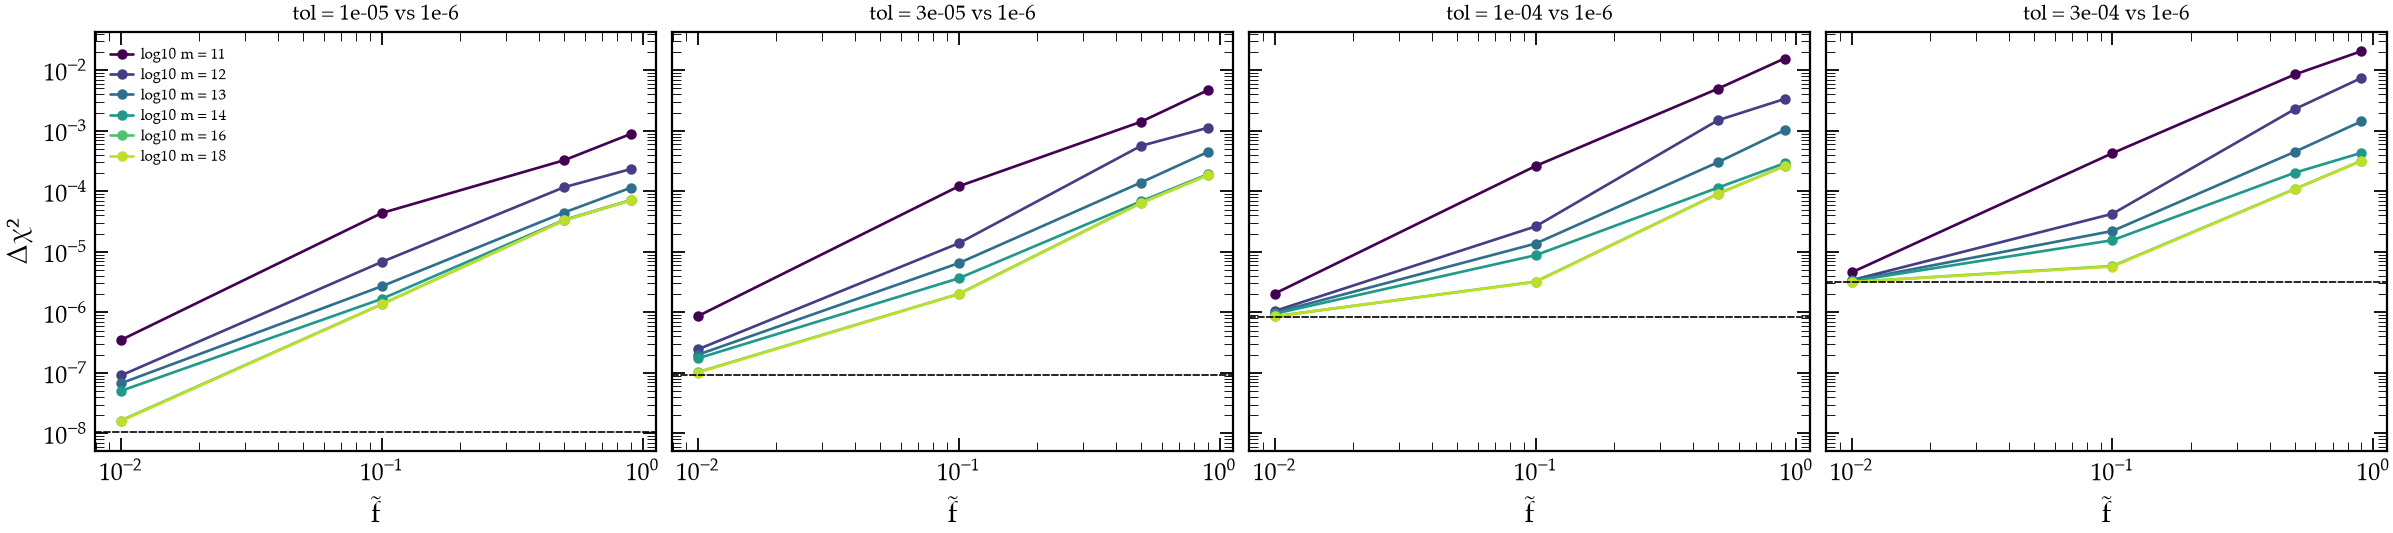

In [3]:
fig, axes = plt.subplots(1, len(TOLS), figsize=(16, 3.6), sharey=True, constrained_layout=True)
for ax, tol in zip(axes, TOLS):
    col = 'Δχ² {:.0e}'.format(tol)
    for c, lm in zip(plt.cm.viridis(np.linspace(0, 0.9, len(MASSES))), MASSES):
        ax.loglog(F_GRID, [table.loc[(lm, ft), col] for ft in F_GRID], 'o-', color=c, ms=4,
                  label='log10 m = {:g}'.format(lm))
    ax.axhline(table.loc[(14, F_NULL), col], color='k', ls='--', lw=0.8)
    ax.set_title('tol = {:.0e} vs 1e-6'.format(tol), fontsize=10)
    ax.set_xlabel('f̃')
axes[0].set_ylabel('Δχ²')
axes[0].legend(fontsize=7)
plt.show()

## 2. Cost

CPU time of full runs (all threads, `time.process_time`), twice each at three points, relative to the
default 1e-5. Wall time follows it but is noisier.

In [4]:
import pickle
import time
from pathlib import Path

from classy import Class

TIMING = Path('20_timing.pkl')
TIME_POINTS, REPEATS = [(11, 0.5), (14, 0.1), (16, 0.9)], 2


def cpu_seconds(p):
    cosmo = Class()
    cosmo.set(p)
    t0 = time.process_time()
    cosmo.compute()
    dt = time.process_time() - t0
    cosmo.struct_cleanup()
    cosmo.empty()
    return dt


cpu = pickle.loads(TIMING.read_bytes()) if TIMING.exists() else {}
for lm, ft in TIME_POINTS:
    for tol in [REF] + TOLS:
        if (lm, ft, tol) not in cpu:
            cpu[(lm, ft, tol)] = [cpu_seconds(params(lm, ft, tol)) for _ in range(REPEATS)]
TIMING.write_bytes(pickle.dumps(cpu))

rel = pd.DataFrame({'{:g}, {:g}'.format(lm, ft): {tol: np.mean(cpu[(lm, ft, tol)])/np.mean(cpu[(lm, ft, 1e-5)])
                                                  for tol in [REF] + TOLS} for lm, ft in TIME_POINTS})
rel['spread'] = [max(np.ptp(cpu[(lm, ft, tol)])/np.mean(cpu[(lm, ft, tol)]) for lm, ft in TIME_POINTS)
                 for tol in rel.index]
show(rel.sort_index(), default='{:.2f}')
print('CPU seconds at 1e-5:', ', '.join('{:.0f}'.format(np.mean(cpu[(lm, ft, 1e-5)])) for lm, ft in TIME_POINTS))

,"11, 0.5","14, 0.1","16, 0.9",spread
0.000001,1.14,1.08,1.12,0.04
0.000010,1.00,1.00,1.00,0.05
0.000030,0.94,0.97,0.93,0.03
0.000100,0.89,0.98,0.89,0.02
0.000300,0.87,1.01,0.87,0.02


CPU seconds at 1e-5: 32, 34, 44


## 3. Where the error sits

Ratios to 1e-6 at the point where 1e-4 is worst.

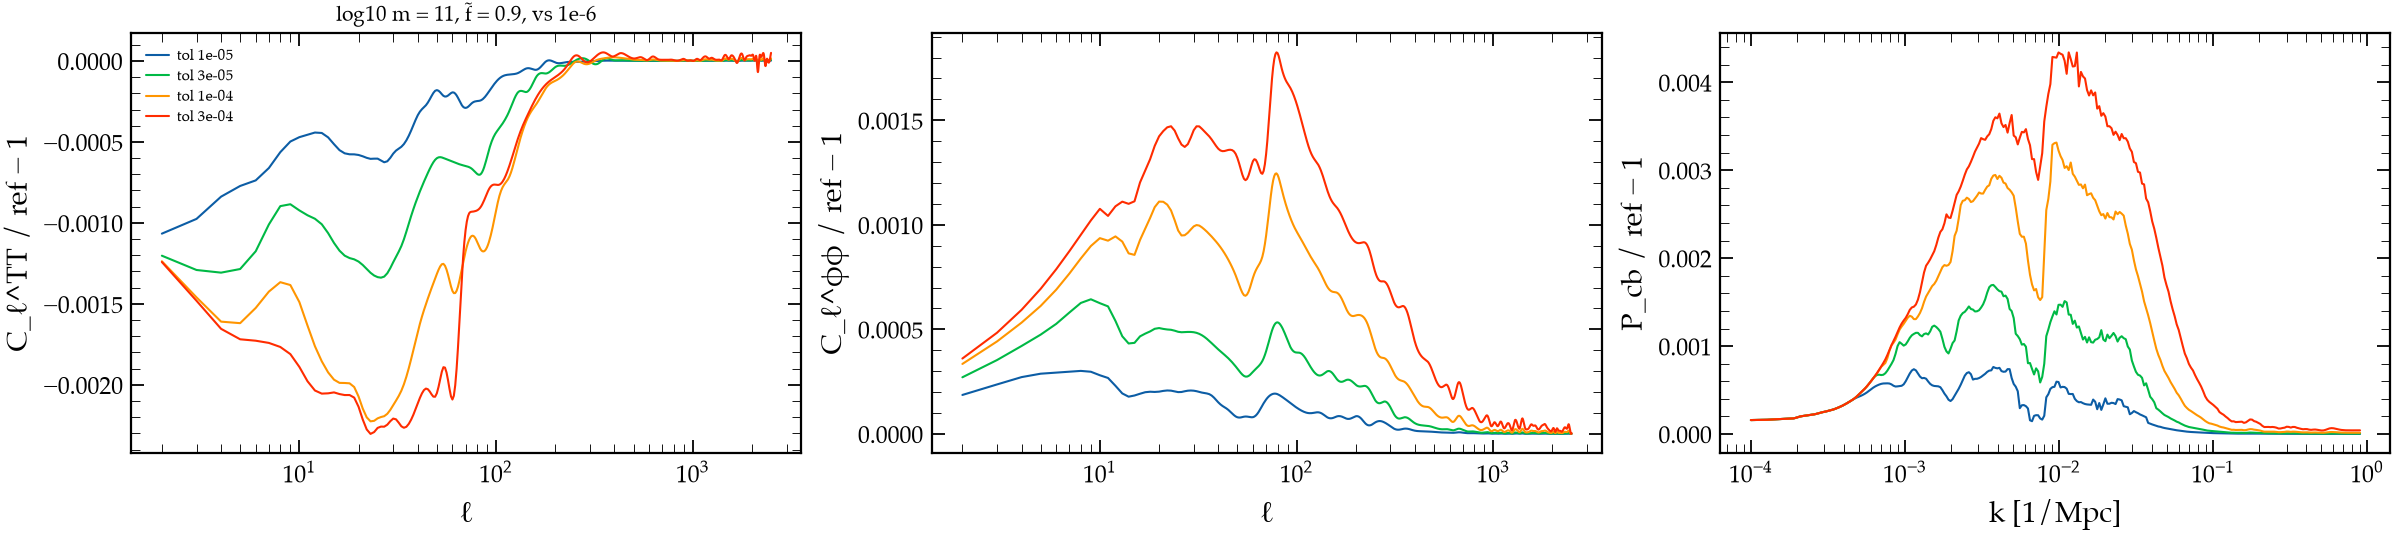

In [5]:
worst = table['Δχ² 1e-04'].drop((14, F_NULL)).idxmax()
ref = res[(*worst, REF)]
fig, axes = plt.subplots(1, 3, figsize=(16, 3.6), constrained_layout=True)
for tol in TOLS:
    out = res[(*worst, tol)]
    axes[0].semilogx(ELL, out['tt']/ref['tt'] - 1, lw=1, label='tol {:.0e}'.format(tol))
    axes[1].semilogx(ELL, out['pp']/ref['pp'] - 1, lw=1)
    axes[2].semilogx(KK, out['pk_cb']/ref['pk_cb'] - 1, lw=1)
axes[0].set_ylabel('C_ℓ^TT / ref − 1')
axes[1].set_ylabel('C_ℓ^φφ / ref − 1')
axes[2].set_ylabel('P_cb / ref − 1')
axes[2].set_xlabel('k [1/Mpc]')
for ax in axes[:2]:
    ax.set_xlabel('ℓ')
axes[0].set_title('log10 m = {:g}, f̃ = {:g}, vs 1e-6'.format(*worst), fontsize=10)
axes[0].legend(fontsize=7)
plt.show()